# 02 · NumPy Fundamentals

**Difficulty:** Beginner-Intermediate | **Time:** ~2.5 hours

NumPy is the backbone of all data science in Python. Every library (pandas, scikit-learn, TensorFlow) uses NumPy arrays internally.

## Table of Contents
1. Why NumPy?
2. Creating Arrays
3. Array Operations & Broadcasting
4. Indexing & Slicing
5. Aggregations
6. Linear Algebra Basics
7. Real-world Example: Image as Array
8. Exercises

## 1. Why NumPy?

In [1]:
import numpy as np
import time

# Speed comparison: Python list vs NumPy array
size = 1_000_000

# Python list
start = time.time()
py_list = list(range(size))
py_result = [x**2 for x in py_list]
py_time = time.time() - start

# NumPy array
start = time.time()
np_arr = np.arange(size)
np_result = np_arr ** 2
np_time = time.time() - start

print(f"Python list:  {py_time:.4f}s")
print(f"NumPy array:  {np_time:.4f}s")
print(f"NumPy is {py_time/np_time:.1f}x faster!")

Python list:  0.1020s
NumPy array:  0.0073s
NumPy is 13.9x faster!


## 2. Creating Arrays

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Different ways to create arrays
a1 = np.array([1, 2, 3, 4, 5])            # from list
a2 = np.zeros((3, 4))                      # all zeros
a3 = np.ones((2, 3))                       # all ones
a4 = np.eye(4)                             # identity matrix
a5 = np.linspace(0, 1, 10)                # evenly spaced
a6 = np.arange(0, 20, 2)                  # like range()
a7 = np.random.randn(3, 3)               # standard normal

print("1D array:", a1)
print("Shape:", a1.shape, "| Dtype:", a1.dtype)
print()
print("Zeros 3×4:")
print(a2)
print()
print("Linspace 0→1:")
print(a5)
print()
print("Random 3×3:")
print(a7.round(3))

1D array: [1 2 3 4 5]
Shape: (5,) | Dtype: int64

Zeros 3×4:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

Linspace 0→1:
[0.         0.11111111 0.22222222 0.33333333 0.44444444 0.55555556
 0.66666667 0.77777778 0.88888889 1.        ]

Random 3×3:
[[ 0.905 -0.072  1.332]
 [-2.18  -1.566  0.561]
 [ 1.569  0.653  0.68 ]]


In [3]:
# Real-world: simulate exam scores for 30 students across 5 subjects
np.random.seed(42)
scores = np.random.randint(40, 100, size=(30, 5))
subjects = ["Math", "Science", "English", "History", "Computer"]

print("Score matrix shape:", scores.shape)
print("First 5 students:")
print(scores[:5])

Score matrix shape: (30, 5)
First 5 students:
[[78 91 68 54 82]
 [47 60 78 97 58]
 [62 50 50 63 92]
 [75 79 63 42 61]
 [92 41 63 83 69]]


## 3. Array Operations & Broadcasting

In [4]:
# Element-wise operations — no loops needed!
a = np.array([1, 2, 3, 4, 5])
b = np.array([10, 20, 30, 40, 50])

print("a + b  =", a + b)
print("a * b  =", a * b)
print("a ** 2 =", a ** 2)
print("sqrt(b)=", np.sqrt(b))

a + b  = [11 22 33 44 55]
a * b  = [ 10  40  90 160 250]
a ** 2 = [ 1  4  9 16 25]
sqrt(b)= [3.16227766 4.47213595 5.47722558 6.32455532 7.07106781]


In [5]:
# Broadcasting — operating on arrays of different shapes
matrix = np.array([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9]])

row_vector = np.array([10, 20, 30])

# NumPy automatically broadcasts row_vector across all rows
result = matrix + row_vector
print("Matrix + row vector (broadcasting):")
print(result)

# Real use: normalize each column to 0-1
col_min = matrix.min(axis=0)  # min per column
col_max = matrix.max(axis=0)  # max per column
normalized = (matrix - col_min) / (col_max - col_min)
print("\nNormalized (0-1 per column):")
print(normalized.round(3))

Matrix + row vector (broadcasting):
[[11 22 33]
 [14 25 36]
 [17 28 39]]

Normalized (0-1 per column):
[[0.  0.  0. ]
 [0.5 0.5 0.5]
 [1.  1.  1. ]]


## 4. Indexing & Slicing

In [6]:
np.random.seed(0)
data = np.random.randint(10, 99, size=(6, 6))
print("Original matrix:")
print(data)
print()

# Basic slicing
print("Row 0:        ", data[0])
print("Column 2:     ", data[:, 2])
print("Top-left 3×3:")
print(data[:3, :3])

# Boolean indexing — very powerful!
print("\nValues > 70:", data[data > 70])
print("Count > 70:", (data > 70).sum())

Original matrix:
[[54 57 74 77 77 19]
 [93 31 46 97 80 98]
 [98 22 68 75 49 97]
 [56 98 91 47 35 87]
 [82 19 30 90 79 89]
 [57 74 92 98 59 39]]

Row 0:         [54 57 74 77 77 19]
Column 2:      [74 46 68 91 30 92]
Top-left 3×3:
[[54 57 74]
 [93 31 46]
 [98 22 68]]

Values > 70: [74 77 77 93 97 80 98 98 75 97 98 91 87 82 90 79 89 74 92 98]
Count > 70: 20


In [7]:
# Fancy indexing — select specific rows/cols
rows = np.array([0, 2, 4])
print("Rows 0, 2, 4:")
print(data[rows])

# Real-world: select top-3 scoring students (using our exam data)
avg_scores = scores.mean(axis=1)            # average per student
top3_idx   = np.argsort(avg_scores)[-3:][::-1]  # indices of top 3
print("\nTop 3 students (index, avg):")
for idx in top3_idx:
    print(f"  Student {idx}: avg = {avg_scores[idx]:.1f}")

Rows 0, 2, 4:
[[54 57 74 77 77 19]
 [98 22 68 75 49 97]
 [82 19 30 90 79 89]]

Top 3 students (index, avg):
  Student 23: avg = 86.0
  Student 9: avg = 81.2
  Student 28: avg = 80.6


## 5. Aggregations

In [8]:
# axis=0 → along columns (per-subject stats), axis=1 → along rows (per-student)
print("Per-subject statistics:")
print(f"{'Subject':<12} {'Mean':>6} {'Std':>6} {'Min':>6} {'Max':>6}")
print("-" * 40)
for i, subj in enumerate(subjects):
    col = scores[:, i]
    print(f"{subj:<12} {col.mean():>6.1f} {col.std():>6.1f} {col.min():>6} {col.max():>6}")

Per-subject statistics:
Subject        Mean    Std    Min    Max
----------------------------------------
Math           72.4   16.5     46     99
Science        65.5   18.5     41     99
English        70.7   19.9     40     99
History        68.4   16.7     42     98
Computer       69.9   17.4     42     99


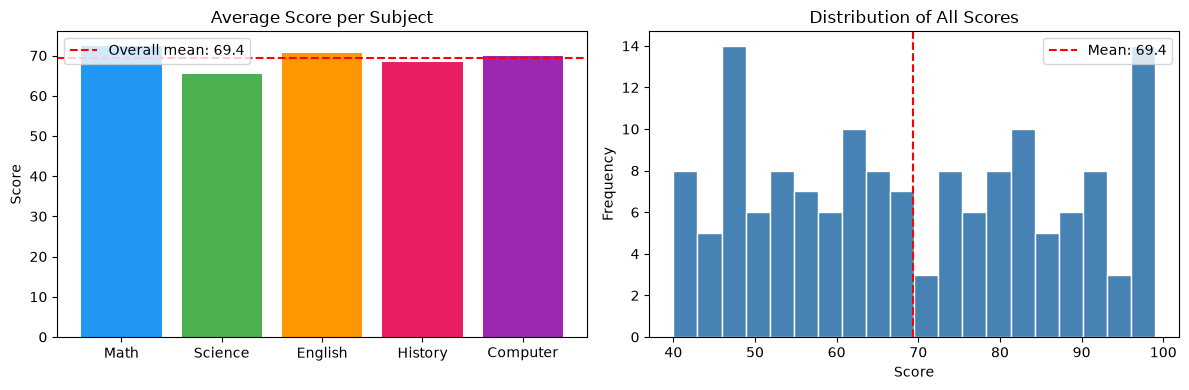

Chart saved!


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart: average score per subject
means = scores.mean(axis=0)
axes[0].bar(subjects, means, color=['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0'])
axes[0].axhline(means.mean(), color='red', linestyle='--', label=f'Overall mean: {means.mean():.1f}')
axes[0].set_title("Average Score per Subject")
axes[0].set_ylabel("Score")
axes[0].legend()

# Histogram: distribution of all scores
axes[1].hist(scores.flatten(), bins=20, color='steelblue', edgecolor='white')
axes[1].axvline(scores.mean(), color='red', linestyle='--', label=f'Mean: {scores.mean():.1f}')
axes[1].set_title("Distribution of All Scores")
axes[1].set_xlabel("Score")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig("/tmp/numpy_scores.png", dpi=100)
plt.show()
print("Chart saved!")

## 6. Linear Algebra Basics

In [10]:
# Matrix multiplication — the core of ML models
A = np.array([[1, 2], [3, 4], [5, 6]])   # 3×2
B = np.array([[7, 8, 9], [10, 11, 12]])  # 2×3

C = A @ B   # matrix multiplication → 3×3
print("A (3×2):")
print(A)
print("\nB (2×3):")
print(B)
print("\nA @ B (3×3):")
print(C)

A (3×2):
[[1 2]
 [3 4]
 [5 6]]

B (2×3):
[[ 7  8  9]
 [10 11 12]]

A @ B (3×3):
[[ 27  30  33]
 [ 61  68  75]
 [ 95 106 117]]


In [11]:
# Solving a linear system: Ax = b
# Real-world: 2 items, 2 prices, find individual prices
# 3 apples + 2 oranges = ₹50
# 1 apple  + 4 oranges = ₹40

A = np.array([[3, 2],
              [1, 4]], dtype=float)
b = np.array([50, 40], dtype=float)

x = np.linalg.solve(A, b)
print(f"Apple price:  ₹{x[0]:.2f}")
print(f"Orange price: ₹{x[1]:.2f}")

# Verify
print("\nVerification:", A @ x, "==", b)

Apple price:  ₹12.00
Orange price: ₹7.00

Verification: [50. 40.] == [50. 40.]


## 7. Real-World Example: Image as a NumPy Array

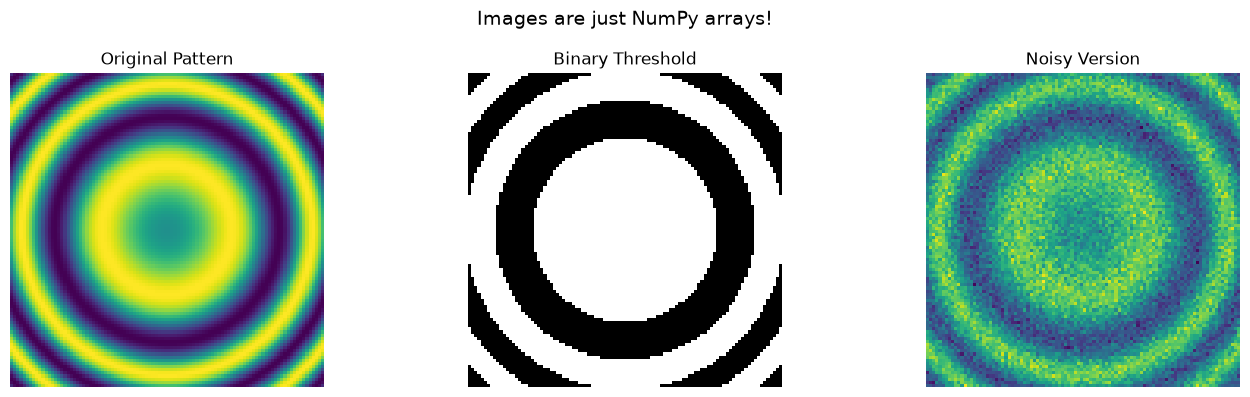

In [12]:
# Every digital image is just a NumPy array of pixel values!
# Let's create a synthetic grayscale image and manipulate it.

size = 100
x = np.linspace(-3, 3, size)
y = np.linspace(-3, 3, size)
X, Y = np.meshgrid(x, y)

# Create a pattern
image = np.sin(X**2 + Y**2)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(image, cmap='viridis')
axes[0].set_title("Original Pattern")
axes[0].axis('off')

# Threshold — binary image
binary = (image > 0).astype(float)
axes[1].imshow(binary, cmap='gray')
axes[1].set_title("Binary Threshold")
axes[1].axis('off')

# Add noise
noisy = image + np.random.normal(0, 0.3, image.shape)
axes[2].imshow(noisy, cmap='viridis')
axes[2].set_title("Noisy Version")
axes[2].axis('off')

plt.suptitle("Images are just NumPy arrays!", fontsize=14)
plt.tight_layout()
plt.savefig("/tmp/numpy_image.png", dpi=100)
plt.show()

## 8. Practice Exercises

In [13]:
# Exercise 1: Without using .mean()/.std(), compute them manually
def manual_stats(arr):
    n = len(arr)
    mean = np.sum(arr) / n
    std  = np.sqrt(np.sum((arr - mean)**2) / n)
    return mean, std

arr = np.array([4, 7, 13, 16, 21])
m, s = manual_stats(arr)
print(f"Manual   → mean={m:.2f}, std={s:.2f}")
print(f"NumPy    → mean={arr.mean():.2f}, std={arr.std():.2f}")

Manual   → mean=12.20, std=6.11
NumPy    → mean=12.20, std=6.11


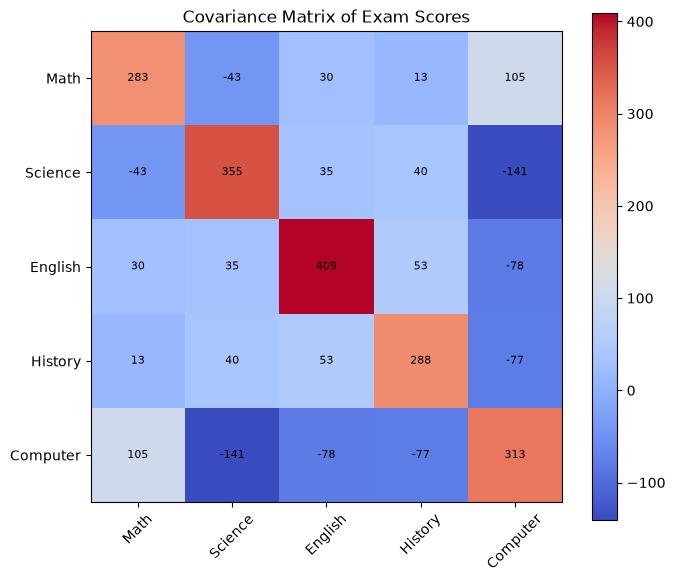

In [14]:
# Exercise 2: Matrix operations — find the covariance matrix of scores
# Covariance matrix tells us how subjects relate to each other
cov_matrix = np.cov(scores.T)   # shape: (5, 5)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cov_matrix, cmap='coolwarm')
ax.set_xticks(range(5)); ax.set_xticklabels(subjects, rotation=45)
ax.set_yticks(range(5)); ax.set_yticklabels(subjects)
plt.colorbar(im, ax=ax)
ax.set_title("Covariance Matrix of Exam Scores")
for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{cov_matrix[i,j]:.0f}', ha='center', va='center', fontsize=8)
plt.tight_layout()
plt.savefig("/tmp/covariance.png", dpi=100)
plt.show()

## Summary

| Concept | Why It Matters |
|---|---|
| ndarray | Core data structure of all ML |
| Broadcasting | Avoid slow Python loops |
| Boolean indexing | Filter data without loops |
| Linear algebra | Foundation of ML algorithms |
| Aggregations | Quick statistics on any axis |

**Next notebook →** `03_Pandas_Data_Analysis.ipynb`